In our journey through data science, we've explored the vast potential of APIs (Application Programming Interfaces) for data retrieval and manipulation. We've learned how to make API requests, extract specific data, and transform this data into usable formats. In this project, we'll integrate these skills to perform practical data extraction and analysis using a financial dataset.

Brief API description: [The Nasdaq Data Link API](https://docs.data.nasdaq.com/docs/in-depth-usage-1) provides a gateway to a wide range of financial data sets, including comprehensive metrics on various companies. We will focus on the MER/F1 data table, which contains detailed financial information such as balance sheets, cash flow statements, and income statements.

We will extract **financial data for a specific set of companies, with an emphasis on understanding their financial performance over time. We'll examine metrics like Accrued Expenses Turnover and explore how these values differ among companies and regions.**

**Our goal:**
 - To perform a detailed analysis of this financial data, including trend analysis and comparative studies.
 - We will use Python for data retrieval, cleaning, and analysis and create visualizations to present our findings effectively.

To succeed in this project, you'll need familiarity with Python, particularly in using APIs, handling JSON data, and employing libraries like Pandas and Matplotlib for data analysis and visualization. While we provide a structured path, we encourage you to explore additional analyses that you find intriguing or relevant.

**Instructions**
- Open a new Jupyter Notebook and perform the following steps:

- Set the title of your project.

- Write a concise introduction in a Markdown cell that outlines:

    - An overview of what the project entails.
    - The primary goal or objectives of the project.


Remember, the title and introduction are preliminary at this stage. You can refine them later once you have a clearer understanding of the project's direction and outcomes after completing the analysis.

## 2 of 10 · API documentation and credentials

The [The Nasdaq Data Link API](https://docs.data.nasdaq.com/docs/in-depth-usage-1) requires an API key for access. If you have already created an account on NASDAQ Data Link, you should have received your API key.

If you haven't obtained an API key yet, please create an account here and follow these steps:

 - Fill in your details, including your first name, last name, and email address.

 - Once you have the account ready, you should be able to find the API key in your Account Settings under your profile.

Securely Handling Your API Key in Jupyter Notebook
 - To keep your API key secure, especially when sharing your Jupyter Notebooks, store it in a separate Python file ( e.g., config.py) and import this file into your notebook.

my API Key -- **YXyPmbWzbsZnMmsbrfTg**

In [41]:
import config
api_key = config.API_KEY

With your API key in hand, the next task is determining the appropriate API endpoint and the parameters needed to query the financial data. For guidance on constructing your query, refer to the [Nasdaq Data Link API documentation](https://docs.data.nasdaq.com/docs/in-depth-usage-1).

Instructions
- Please review the [Nasdaq Data Link API documentation](https://docs.data.nasdaq.com/docs/in-depth-usage-1) to understand its API usage

    - Identify the base URL and the main table name in the URL for accessing Tables' data.
    - Determine the query parameters and filterable columns supported by this API.
    - Review the rate limits and guidelines for usage of this API.

In [42]:
import pandas as pd
import requests

# base url

api_url='https://data.nasdaq.com/api/v3/datatables/MER/F1.json'

# our `parameters` dictionary

parameters = {
    'api_key': api_key,
    'qopts.per_page': 10  # Number of rows to fetch

}

# Fetching the data and converting it to json

json_data=requests.get(api_url, params=parameters).json()

# printing the json data

print(json_data)

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1868216112, -1802, 8.161754, '2011-09-30', 'Q3', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1885063456, -1802, 10.788213, '2012-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60

## 3 of 10 · Working with the Endpoint and Parameters to Query the API

Continuing from our previous discussion on understanding the Nasdaq API usage, here's a summary of key findings from the documentation:

Key Elements from the Nasdaq Data Link API Documentation:
Base URL Structure:

 - Access MER/F1 table in JSON format: https://data.nasdaq.com/api/v3/datatables/MER/F1.json.

Optional Query Parameters:

 - Limit rows per request: qopts.per_page=10.
 - Filter by 'ticker' column value 'SPY': ticker=SPY.
 - Specify columns in the response: qopts.columns=ticker, date, shares_outstanding.
 - Filter rows by multiple 'ticker' values: ticker=SPY, IWM, GLD.

This summary provides an overview of the optional query parameters and URL structures for customizing data queries with the Nasdaq Data Link API, particularly for the MER/F1 table.

Instructions
 - Import requests, pandas, and matplolib libraries.
 - Import your API key from config.py.
 - Identify and store the API URL needed to extract the financial data in JSON format in a variable named api_url.
 - Create a parameters dictionary with your API key and the parameter qopts.per_page.

     - Initially set qopts.per_page to 10 to fetch a small sample of the data.
     - The api_key parameter should contain your API key from the config.py file.

Fetch data using requests.get, passing parameters, and convert the response to JSON.
  - Store the data in json_data and print it to check the output.

What can you tell from the output?

In [43]:
import pandas as pd
import requests
import matplotlib as mlt

In [44]:
import pandas as pd
import requests
import matplotlib as mlt

import config
api_key = config.API_KEY

# base url

api_url='https://data.nasdaq.com/api/v3/datatables/MER/F1.json'

# our `parameters` dictionary

parameters = {
    'api_key': api_key,
    'qopts.per_page': 10  # Number of rows to fetch

}

# Fetching the data and converting it to json

json_data=requests.get(api_url, params=parameters).json()

# printing the json data

print(json_data)

api_url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json'
parameters = {
    'api_key': api_key,
    'qopts.per_page': 10000  

}
json_data=requests.get(api_url, params=parameters).json()

data = json_data['datatable']['data']
columns = [col['name'] for col in json_data['datatable']['columns']]

# Create DataFrame from a list of list
df_metric = pd.DataFrame(data, columns=columns)
df_metric.head()

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1868216112, -1802, 8.161754, '2011-09-30', 'Q3', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1885063456, -1802, 10.788213, '2012-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived


## 4 of 10 · Processing the JSON Data into a DataFrame

On the previous screen, we printed the JSON data for up to 10 entries. If you look at the first entry:



[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2022-12-31', 'Accrued Expenses Turnover', 'Derived']

This row indicates that for Deutsche Bank AG, in the second quarter (Q2) of 2011, the Accrued Expenses Turnover ratio was approximately 10.48. This suggests that during this quarter, Deutsche Bank effectively managed its short-term liabilities by cycling through its accrued expenses roughly 10.48 times. A high turnover ratio like this implies efficient management of short-term obligations, provided this figure aligns with industry standards and the company's norms.

These kinds of insights are achievable mainly when we work with datasets that are not too large or complex. Remember, our goal is to analyze trends in Accrued Expenses Turnover across different companies and understand how various regions contribute to these financial metrics. However, discerning these trends by just reading through JSON data can be extremely challenging.

To address this, we will focus on converting the JSON data received from the API into a pandas DataFrame for this part of the project. This will enable us to handle and analyze the data more effectively.

{
    "datatable": {
        "data": [
            [2438, 1868192544, -1802, 10.481948, "2011-06-30", "Q2", ...],
            [2438, 1868216112, -1802, 8.161754, "2011-09-30", "Q3", ...],
            ...
        ],
        "columns": [
            {"name": "compnumber", "type": "Integer"},
            {"name": "reportid", "type": "Integer"},
            ...
        ]
    },
    ...
}

This structure shows that the data key holds the actual data in a list of lists format, where each inner list represents a row of data. The columns key contains a list of dictionaries, each providing the name and type of a column.

Before processing the actual JSON data, let's understand how to create a pandas DataFrame from a list of lists. This method is essential for handling the data format in our JSON response.

In [45]:
import pandas as pd
import requests
import matplotlib as mlt

import config
api_key = config.API_KEY

# base url

api_url='https://data.nasdaq.com/api/v3/datatables/MER/F1.json'

# our `parameters` dictionary

parameters = {
    'api_key': api_key,
    'qopts.per_page': 10  # Number of rows to fetch

}

# Fetching the data and converting it to json

json_data=requests.get(api_url, params=parameters).json()

# printing the json data

print(json_data)

api_url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json'
parameters = {
    'api_key': api_key,
    'qopts.per_page': 10000  

}
json_data=requests.get(api_url, params=parameters).json()

data = json_data['datatable']['data']
columns = [col['name'] for col in json_data['datatable']['columns']]

# Create DataFrame from a list of list
df_metric = pd.DataFrame(data, columns=columns)
df_metric.head()

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1868216112, -1802, 8.161754, '2011-09-30', 'Q3', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1885063456, -1802, 10.788213, '2012-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived


## 5 of 10 · Understanding the Dataset

Now that we have our JSON data in a pandas DataFrame, we can utilize various methods provided by pandas to work with our data more comfortably. 

For instance, we can run **df_metric.info()** to gain insights into the various columns of our dataset or **df_metric.shape** to determine the number of rows and columns. Methods like **df.groupby, df.apply(), df.describe()**, and others will also be helpful. 

Our goals and objectives will always guide our choice of method.

Recall that we had two primary aims:

 - To analyze the financial trend of 'accrued expenses turnover' over a period for various companies, particularly banks.
 - To examine how different regions contribute to these financial metrics.

With these aims in mind, we can start to determine which columns in our dataset will help us achieve these goals and the type of data cleaning needed for accurate analysis.

Here's a detailed overview of the key columns and their descriptions:

| Column Name | Description                                                 |
|-------------|-------------------------------------------------------------|
| compnumber  | Unique identifier for each company                          |
| reportid    | ID associated with a specific financial report              |
| mapcode     | Code representing a specific financial metric or data point |
| amount      | Numerical value of the financial metric                     |
| reportdate  | Date of the financial report                                |
| reporttype  | Type of the report (e.g., Q1, Q2)                           |
| currency    | Currency in which financial amounts are reported            |
| longname    | The name of the bank or company                             |
| city        | The city to which a given bank or company belong            |
| country     | Region to which a given bank or company is situated         |
| ...         | ...                                                         |
| indicator   | Specific financial indicator being reported                 |
| statement   | Type of financial statement from which the data is derived  |

Note: This table is a simplified view focusing on key columns. The actual dataset contains more columns with various data types.

Instructions
- Reflect on the information provided by the info() method and the column overview. Identify the columns necessary for trend and comparative analysis.

- In your Jupyter Notebook, create a variable named necessary_columns and store the names of these crucial columns:

  - Give reasons why these columns seems to be much important


By understanding the structure and type of data each column represents, you can make more informed decisions in your data analysis process, leading to more accurate and insightful results.

In [46]:
df_metric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 non-null  object 
 18  address

In [47]:
necessary_columns=['reportid','reportdate','reporttype','amount','longname','country','region','indicator','statement']

## 6 of 10 · Filtering the DataFrame for Analysis

We've noticed that columns like **indicator, country, longname, reportdate, reporttype, and amount** are crucial for our analysis. They help us analyze financial trends and make regional comparisons.

Now that we have identified the essential columns, the next step is to refine our analysis. 

Recall that our primary focus is on a specific financial metric—the accrued expenses turnover. 

Our DataFrame, df_metric, contains various indicators, so it's important to filter for rows that specifically mention this financial metric.

**"Accrued Expenses Turnover"** is a key financial efficiency ratio. 
It measures how often a company pays off its accrued expenses within a certain period, providing insights into:

**Cash Flow Management**: It indicates how well a company is managing its cash flow in relation to its short-term obligations. A higher ratio suggests efficient management and a strong liquidity position.

**Operational Efficiency**: This metric can reflect a company's operational efficiency, showing how promptly it settles its short-term debts.

**Financial Health Indicator**: Regular payment of accrued expenses signifies good financial health and creditworthiness, which is essential for maintaining good supplier relationships and business stability.

Before applying these concepts to our main dataset, let's understand the process using a dummy dataset:

# Dummy dataset
dummy_data = {
    'compnumber': [1, 2, 3],
    'reportdate': ['2020-01-01', '2020-01-02', '2020-01-03'],
    'indicator': ['Accrued Expenses Turnover', 'Other Metric', 'Accrued Expenses Turnover'],
    'amount': [10.5, 20.75, 30.0],
    'exchange': ['NYSE', 'NASDAQ', 'NYSE']
}

dummy_df = pd.DataFrame(dummy_data)

To filter this DataFrame, we'll perform two steps:

Instructions:

1) Using your DataFrame df_metric that contains the data from the API apply the same filtering steps:

    - Select only the columns stored in your necessary_columns variable.
    - Filter the DataFrame to include only rows where the indicator column value is Accrued Expenses Turnover.
    - Store the result back to a new DataFrame called filtered_df.

In [48]:
# Selecting only necessary columns
df_metric=df_metric[necessary_columns]
filtered_df=df_metric[df_metric['indicator']=='Accrued Expenses Turnover']
filtered_df['indicator'].describe()

count                           139
unique                            1
top       Accrued Expenses Turnover
freq                            139
Name: indicator, dtype: object

## 7 of 10 · Enhancing the DataFrame

From the previous screen, we deduced that the average Accrued Expenses Turnover ratio for companies is around 26.91, with a wide range from 4.69 to 229.81. 
This variation signifies diverse financial management strategies among companies. 


The standard deviation of 33.10 suggests substantial differences in how companies manage their short-term liabilities, influenced by factors like industry and company size.

Enhancing the readability and information quality of our DataFrame is crucial for clear analysis and reporting. 


We will focus on two enhancements: 
 - adding a column with full country names and cleaning up the column names.

**Full Country Names:** The current country column uses abbreviations, which might not be immediately recognizable. Including full country names makes the data more understandable and accessible, especially for those unfamiliar with country codes.

**Column Name Cleaning:** Using consistent naming conventions, like snake_case, improves code readability and maintainability. Renaming 'longname' to 'company_name' clarifies the column's purpose.

We'll use the **apply()** method on the country column to create a new column with full country names. This method allows us to apply a custom operation to each element in a column.

First, let's create a simple dictionary to map country abbreviations to full names:

In [49]:
country_mapping = {
    'USA': 'United States of America',
    'DEU': 'Germany',
    'JPN': 'Japan',
    'CYM': 'Cayman Islands',
    'BHS': 'Bahamas',
    'IRL': 'Ireland'   
}

Instructions
 - Define a function that takes a country name and returns its full name. This function will handle various country names and map them to their full names(e.g., 'USA' to 'United States of America').
 - Use the apply() method to apply your function to the country column in your DataFrame filtered_df. Store the results in a new column called country_name.
 - Update the column name to use the snake_case naming convention. Also, make sure to name the column longname as company_name.
 - Assign the result back to a new DataFrame called updated_df.
 - Apply the value_counts() method on the country_name column to get the frequency of the countries in our DataFrame.

In [51]:
def update_country_name(name):
    if name=='USA':
        name='United State of America'
    elif name=='JPN':
        name='Japan'
    elif name=='CYM':
        name='Cayman Islands'
    elif name=='BHS':
        name='Bahamas'
    elif name=='DEU':
        name='Germany'
    else:
        name='Ireland'
    
    return name


filtered_df=filtered_df.copy()
filtered_df['country_name']=filtered_df['country'].apply(update_country_name)
filtered_df.columns=['report_id','report_date','report_type',
                   'amount','company_name','country','region',
                   'indicator','statement','country_name']
updated_df=filtered_df.copy()
updated_df['country_name'].value_counts()

country_name
United State of America    31
Ireland                    29
Japan                      27
Cayman Islands             27
Bahamas                    19
Germany                     6
Name: count, dtype: int64

## 8 of 10 · Understanding Financial Trends Over Time

So far, we have successfully extracted data from the Nasdaq API using GET requests, utilized optional query parameters like <mark>qopts.per_page</mark> to tailor the output to our needs, read the JSON data into a pandas DataFrame, and explored various pandas methods and functions. We will now advance by visualizing financial trends for various companies over time.

In business analysis and decision-making, understanding the evolution of certain financial metrics over time is crucial. This insight allows analysts and decision-makers to identify patterns, assess the health and performance of the business, and make informed predictions about future trends. Focusing on a specific time period enables analysts to conduct a more detailed and relevant analysis, as different periods can exhibit varying trends due to factors such as market conditions, seasonal effects, or company-specific events.

Understanding financial trends over time is vital for sound business analysis and decision-making. In this section, we concentrate on extracting relevant data for a specific time period(2010-2015) and visualizing trends using matplotlib, a powerful plotting library in Python.

Key Concepts
 - Time Period Filtering: Narrowing down the dataset to a specific, relevant time frame, such as 2010-2015.
 - Column Selection: Choosing essential columns like 'company_name', 'report_date', and 'amount' for focused analysis.
 - Trend Visualization: Using matplotlib to create line plots illustrating how financial metrics change over the selected period.

First, ensure report_date is in the correct format and filter the DataFrame:

In [52]:
# Convert 'report_date' to datetime and filter for 2010-2015
updated_df['report_date'] = pd.to_datetime(updated_df['report_date'])
updated_df = updated_df[(updated_df['report_date'].dt.year >= 2010) & (updated_df['report_date'].dt.year <= 2015)]

1. Select only the relevant columns needed for your trend analysis. In this case, it's assumed you need company_name, report_date, and a metric column like amount. Store the result in a new DataFrame called relevant_data.

2. Begin by iterating over each unique company name in the company_name column of the relevant_data DataFrame.

    - Inside the loop, create a new DataFrame company_data by filtering relevant_data for each specific company. This ensures that company_data only contains rows where the company_name matches the current company in the loop.
    - Use plt.plot() to plot the financial data for each company.
    - Set the report_date column as the x-axis and the amount column as the y-axis.
    - Label each plot with the respective company name, which helps identify the data series in the plot.
    
3. Use the plt.legend() function to add a legend to your plot. The legend provides a key to the different data series (in this case, companies) displayed in the plot.
    - Include the title( e.g. company) parameter in the plt.legend() function to set a title for the legend.
    - Use the bbox_to_anchor parameter to specify the legend's position relative to the plot. The coordinates (1.05, 1), for example, place the legend outside the plot, just to the right of the top corner.
    - Specify the location of the legend. The loc parameter determines the corner of the legend box at the coordinates specified in bbox_to_anchor. By setting loc='upper left', you anchor the upper left corner of the legend box to the specified coordinates.
4. Customize your plot with titles, labels, and a legend to improve the readability and understanding of the data.

5. Run plt.show() to see the graph. Analyze the chart to understand how different companies compare in terms of the average financial metric.

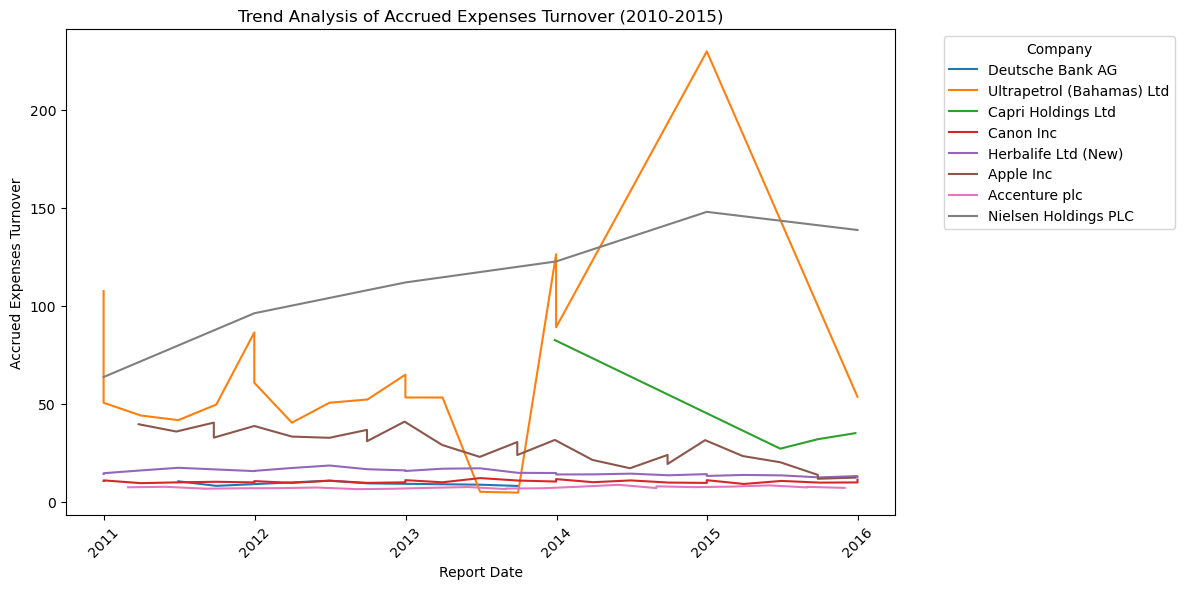

In [53]:
import matplotlib.pyplot as plt


# # Filter for the time period 2010 to 2015
updated_df['report_date'] = pd.to_datetime(updated_df['report_date'])
updated_df = updated_df[(updated_df['report_date'].dt.year >= 2010) & (updated_df['report_date'].dt.year <= 2015)]

# Selecting relevant columns. Assuming 'company_name' is the column with company names.
# Replace 'company_name', 'reportdate', and 'metric_value_column' with actual column names.
relevant_data = updated_df[['company_name', 'report_date', 'amount']].copy()

# Plotting the trend
plt.figure(figsize=(12, 6))

for company in relevant_data['company_name'].unique():
    company_data = relevant_data[relevant_data['company_name'] == company]
    plt.plot(company_data['report_date'], company_data['amount'], label=company)

plt.title('Trend Analysis of Accrued Expenses Turnover (2010-2015)')
plt.xlabel('Report Date')
plt.ylabel('Accrued Expenses Turnover')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9 of 10 · Geographical Region Analysis

On the previous screen, we were able to visualize the financial trends for various companies, highlighting their Accrued Expenses Turnover from 2010 to 2015. The graph depicts each company's financial efficiency, with lines tracing how frequently they managed to pay off their accrued expenses over the six-year period. While some companies show dramatic variances, like UltraPetrol (Bahamas) with a significant spike in 2014, others, like Apple Inc. and Accenture plc, display more stable trends. This visualization allows us to compare and analyze the companies' financial practices and efficiency in managing short-term liabilities during the observed years.

After successfully visualizing financial trends over time, we now shift our focus to analyzing data based on geographical regions. This involves grouping data to understand how different regions contribute to the financial metrics.

Understanding the performance of different geographical regions and stock exchanges is crucial in global financial analysis. It allows us to identify which regions are performing well and which may need more attention or investment.

Now, we'll utilize the power of pandas for data aggregation and matplotlib for visualization to analyze our financial data.

Key Concepts
 - Geographical Region Analysis: Grouping data by country and calculating metrics such as the average financial amount enables a deep understanding of regional performance, highlighting disparities and trends across different markets. This method is essential in global financial analysis, offering insights into each region's economic impact and guiding strategic business decisions and resource allocation based on regional strengths and weaknesses


First, we'll group the data by geographical regions:

In [54]:
# Grouping data by country and calculating the average of the 'amount'
country_avg = updated_df.groupby('country_name')['amount'].mean()

 - Start by grouping the data in updated_df by the country_name column. This will allow you to analyze the financial data by geographical region

   - Calculate the average of a financial metric, such as amount, for each country. Store this in a variable called country_avg.
   - Plot the results of the :

   - Use plt.figure() to set the size of the plot.

 - Plot country_avg using the plot() function with kind='bar' to create a bar chart.
 - Use plt.title(), plt.xlabel(), and plt.ylabel() to add a title and labels to the x-axis and y-axis, respectively.
 - Use plt.xticks(rotation=45) to rotate the x-axis labels for better readability.
 - Apply plt.tight_layout() for an optimized layout.
 - Finally, use plt.show() to display the plot. Analyze the bar chart to understand how different countries compare in terms of the average financial metric.

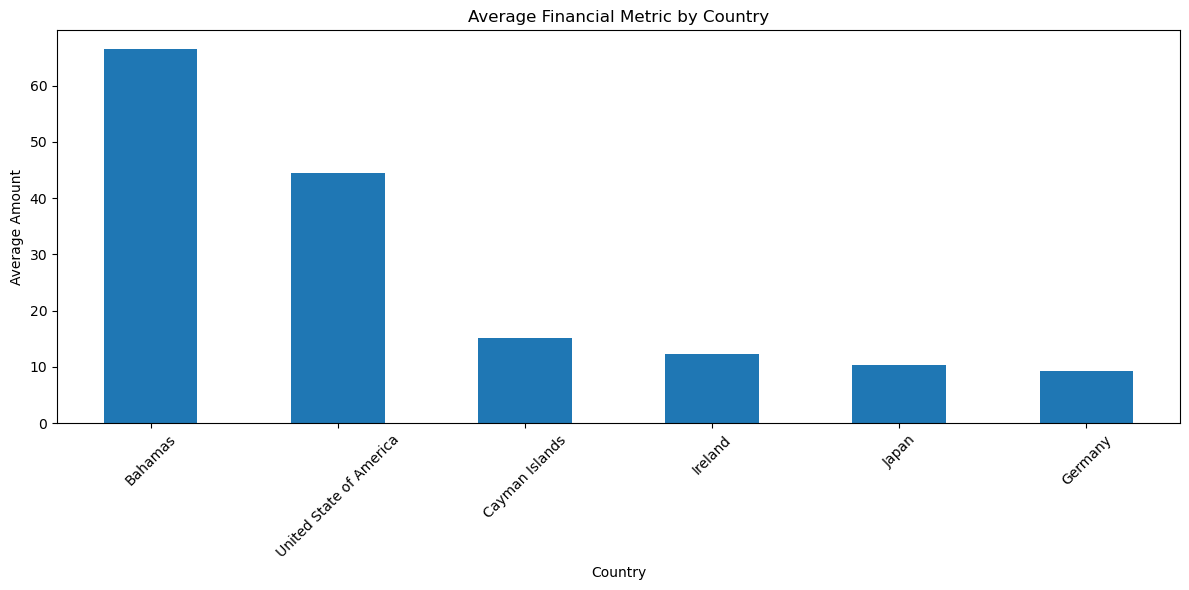

In [55]:
# Plotting for Geographical Region Analysis
plt.figure(figsize=(12, 6))
country_avg.sort_values(ascending=False).plot(kind='bar')
plt.title('Average Financial Metric by Country')
plt.xlabel('Country')
plt.ylabel('Average Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10 of 10 · Next steps

Through this project, we've accomplished several key learning objectives:

We've learned how to make API requests to retrieve financial data from the NASDAQ Data Link API.

We've become adept at working with authentication and JSON data, including filtering and extracting specific information needed for our analysis.

A crucial skill we developed is transforming JSON data into Pandas DataFrames, enabling more sophisticated data manipulation.

We've explored our DataFrames in-depth, understanding their structure and content, which is vital for effective data analysis.

We've performed data cleaning, refining our datasets for accuracy and clarity, enhancing them for more insightful analysis.

We've used matplotlib to visualize financial trends, particularly focusing on Accrued Expenses Turnover to gain deeper insights.

In the code solution provided, we explored one specific approach to conducting data analysis. It's important to note that this is just one of many possible methods. Your approach may differ, and that's completely acceptable. The key is that your solution should successfully handle data analysis and visualization, effectively using Python's capabilities, such as pandas for data manipulation and matplotlib for visualization. As long as your project achieves its objectives and effectively analyzes the financial data, different methods or conclusions are part of the learning and discovery process in data science.

You can find the solution to this project here. Curious to see what other students have done on this project? Head over to our Community to check them out. While you are there, share your own feedback!

And, of course, we welcome you to share your own project and show off your hard work. Head over to our Community to share your finished Guided Project!

Here are a few next steps you could take:

Extend your analysis to include more years or different financial metrics. This can provide a broader view of the trends and performance over time.
Further refine the data cleaning process to handle more complex scenarios. This might include dealing with missing values or outliers that can affect the accuracy of your analysis.
Compare financial metrics across different industries or sectors to understand how they fare against each other in various economic conditions.
Consider other indicators, and try to understand the performance of various companies.